# Variable Inclusion Examples

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import genbart as gb

In [2]:
conf_color = '#227018'
fill_color = '#44f02e'

bart_colors = {
    "red": "#CC2936",
    "blue": "#08415C",
    "green": "#28721D",
    "yellow": "#EEBA0B",
    "brown": "#70201F",
    "gray": "#737373"
}

plt.style.use("bart_style.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Simple example - RegBART

In [3]:
x = np.random.rand(100, 5)
y = x[:, 0] + np.random.normal(scale=0.1, size=100)

selector = gb.BartVariableSelection(
    model_cls=gb.RegBart,
    model_params={
        "m": 20,
        "n_burn": 100,
        "n_samples": 200
    },
    n_permutations=20,
    n_repeats=10,
    random_state=0,
    verbose=False
)

result = selector.fit(x, y)

In [13]:
result.feature_names

['x0', 'x1', 'x2', 'x3', 'x4']

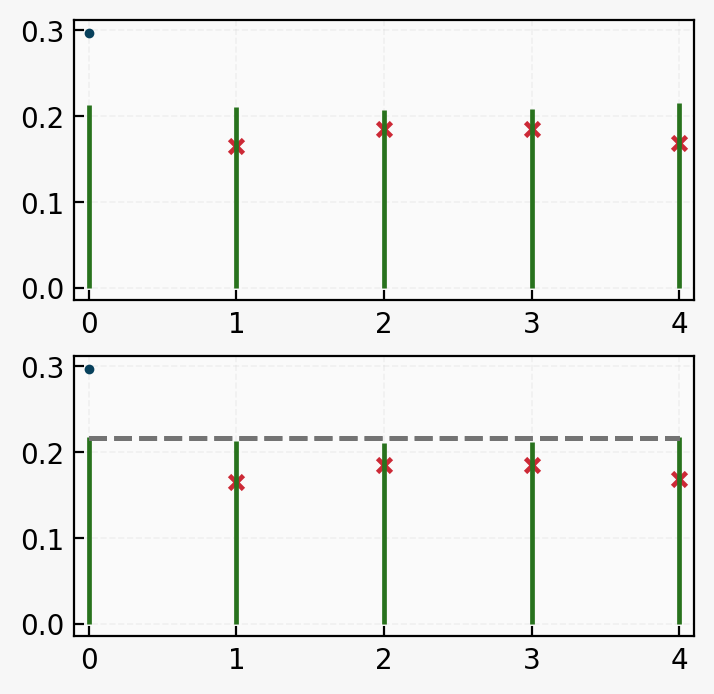

In [27]:
fix, axes = plt.subplots(2, 1, figsize=(4, 4), dpi=200)
x = np.arange(5)
lows = np.zeros(5)
labels = result.feature_names

axes[0].vlines(x,
               lows,
               result.thresholds("local"),
               color=bart_colors["green"])
mask = result.selected_mask("local")
axes[0].scatter(x[mask],
                result.real_vips[mask],
                marker='.',
                color=bart_colors["blue"])
axes[0].scatter(x[~mask],
                result.real_vips[~mask],
                marker='x',
                color=bart_colors["red"])

axes[1].vlines(x,
               lows,
               result.thresholds("global_se"),
               color=bart_colors["green"])
mask = result.selected_mask("global_se")
axes[1].scatter(x[mask],
                result.real_vips[mask],
                marker='.',
                color=bart_colors["blue"])
axes[1].scatter(x[~mask],
                result.real_vips[~mask],
                marker='x',
                color=bart_colors["red"])
axes[1].hlines(result.thresholds("global_max"),
               0, 4,
               color=bart_colors["gray"],
               linestyles='dashed')

plt.show()

## Simple example - ProbitBART

In [29]:
x = np.random.rand(100, 5)
y = np.where(x[:, 0] + np.random.normal(scale=0.1, size=100) < 0.5, 0, 1)

selector = gb.BartVariableSelection(
    model_cls=gb.ProbitBart,
    model_params={
        "m": 20,
        "n_burn": 100,
        "n_samples": 200
    },
    n_permutations=20,
    n_repeats=10,
    random_state=0,
    verbose=False
)

result = selector.fit(x, y)

In [30]:
result.feature_names

['x0', 'x1', 'x2', 'x3', 'x4']

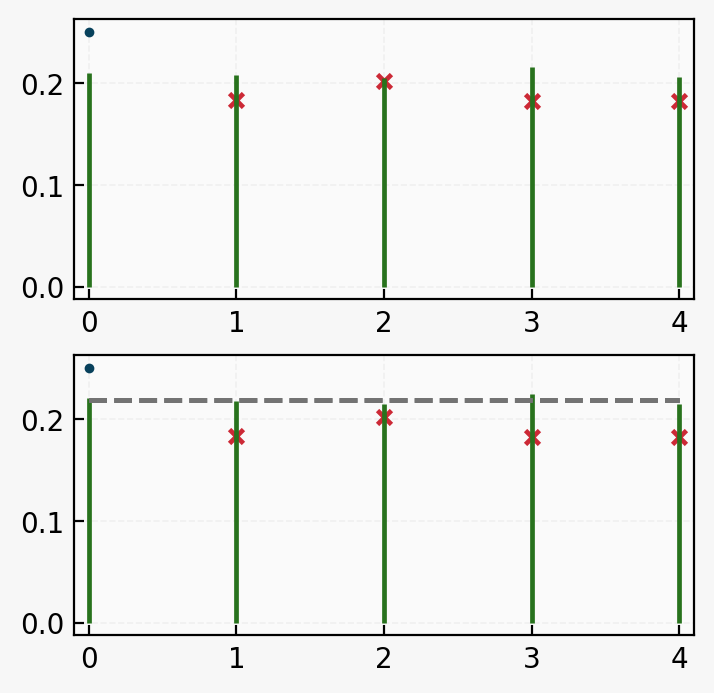

In [31]:
fix, axes = plt.subplots(2, 1, figsize=(4, 4), dpi=200)
x = np.arange(5)
lows = np.zeros(5)
labels = result.feature_names

axes[0].vlines(x,
               lows,
               result.thresholds("local"),
               color=bart_colors["green"])
mask = result.selected_mask("local")
axes[0].scatter(x[mask],
                result.real_vips[mask],
                marker='.',
                color=bart_colors["blue"])
axes[0].scatter(x[~mask],
                result.real_vips[~mask],
                marker='x',
                color=bart_colors["red"])

axes[1].vlines(x,
               lows,
               result.thresholds("global_se"),
               color=bart_colors["green"])
mask = result.selected_mask("global_se")
axes[1].scatter(x[mask],
                result.real_vips[mask],
                marker='.',
                color=bart_colors["blue"])
axes[1].scatter(x[~mask],
                result.real_vips[~mask],
                marker='x',
                color=bart_colors["red"])
axes[1].hlines(result.thresholds("global_max"),
               0, 4,
               color=bart_colors["gray"],
               linestyles='dashed')

plt.show()